In [88]:
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [44]:
adata_path="/project/GCRB/Hon_lab/s223695/Data_project/20241017_TFperturb_CM_timecourse/spatial_comparison/data/overall_merfish.h5ad"
adata = sc.read_h5ad(adata_path)

In [93]:
adata.obs.head()

,sample_id,batch,n_counts,leiden,zone_cluster,communities,complexity,populations,purity
6-R77_4C4,R77_4C4,R77_4C4,86.0,6,4,AVN/AV Ring,8,VIC,0.544534
8-R77_4C4,R77_4C4,R77_4C4,148.0,6,1,Valve,8,VIC,0.625984
9-R77_4C4,R77_4C4,R77_4C4,100.0,6,1,Valve,8,VIC,0.583665
10-R77_4C4,R77_4C4,R77_4C4,70.0,6,1,Valve,9,VIC,0.766393
12-R77_4C4,R77_4C4,R77_4C4,63.0,6,1,Valve,8,VIC,0.596838


In [68]:
tpm_count = np.exp(adata.X)-1

In [71]:
tpm_count.shape

(228635, 238)

In [72]:
mean_val = tpm_count.sum(axis=1).mean()

In [80]:
total_count_arr = adata.obs["n_counts"].values
total_count_arr_scale = total_count_arr/mean_val

In [85]:
raw_count = tpm_count * total_count_arr_scale.reshape(-1, 1)
raw_count = np.round(raw_count)

In [90]:
adata_raw = adata.copy()
adata_raw.X = raw_count

In [87]:
raw_count.sum(axis=1)

array([ 86., 148., 100., ...,  70., 118.,  72.], dtype=float32)

In [96]:
adata_raw.write("./data/overall_merfish_raw.h5ad")

### Visualize Some important genes

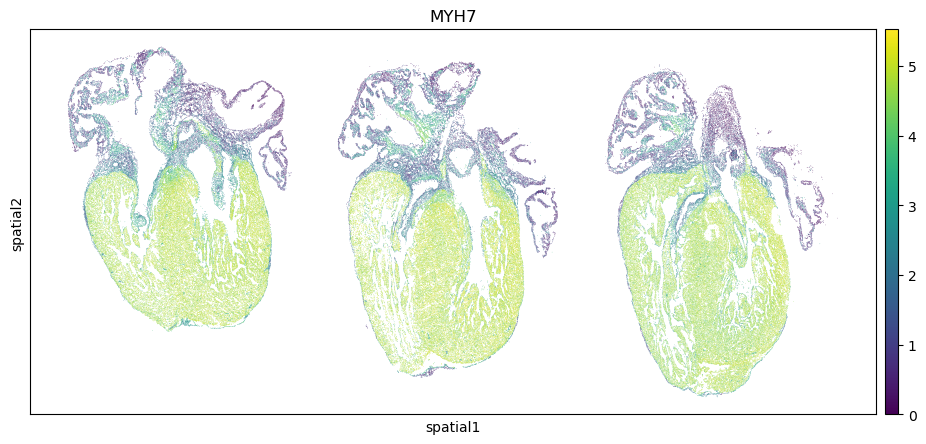

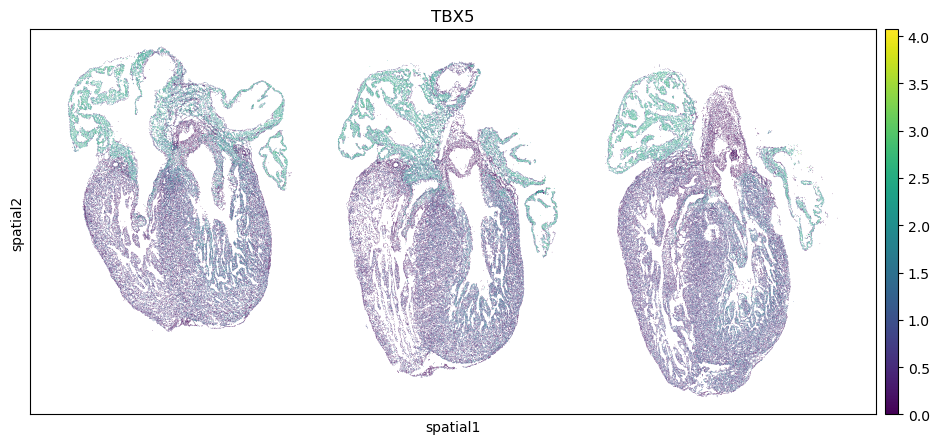

In [100]:
fig,ax = plt.subplots(figsize=(12,5))
sc.pl.embedding(adata,"spatial",color=["MYH7"],ax=ax)
plt.show()

fig,ax = plt.subplots(figsize=(12,5))
sc.pl.embedding(adata,"spatial",color=["TBX5"],ax=ax)
plt.show()